**Thư viện Machine Learning và phân tích dữ liệu**

In [1]:
pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# Tải dữ liệu
from google.colab import files
files.upload()    # ads_data.csv

Saving ads_data.csv to ads_data.csv


{'ads_data.csv': b'Advertising Cost (USD),Sales Revenue (USD)\n784,5167.683485453761\n659,4736.040926226243\n729,4799.105661803958\n292,2307.039663115264\n935,5917.849077653243\n863,5753.385394999056\n807,5348.687785701726\n459,3390.113448871024\n109,841.3006619800116\n823,5324.660475913609\n377,2713.5700971514793\n854,5926.8782567448025\n904,5857.388519711735\n699,4703.47296345806\n170,1812.548089489681\n572,4239.005825823837\n700,4813.288007605864\n496,3505.853018342467\n414,2768.344399483382\n805,5609.094454061213\n586,4373.4968091126\n651,4292.096547221851\n187,1657.0773065338424\n274,2051.4988921127856\n700,4482.839880904874\n949,6321.947198987094\n777,5084.827332711381\n637,4166.847529325185\n945,6369.142269729411\n172,1145.3590441185768\n877,5811.706125485938\n215,1783.7509329152097\n855,5602.105207502065\n809,5315.8688041574715\n947,6271.727505498107\n'}

In [4]:
# Đọc dữ liệu
df = pd.read_csv('ads_data.csv')
df

,Advertising Cost (USD),Sales Revenue (USD)
0,784,5167.683485
1,659,4736.040926
2,729,4799.105662
3,292,2307.039663
4,935,5917.849078
5,863,5753.385395
6,807,5348.687786
7,459,3390.113449
8,109,841.300662
9,823,5324.660476


**Scatter plot (biểu đồ phân tán) để biểu diễn mỗi quan hệ giữa 2 bên**

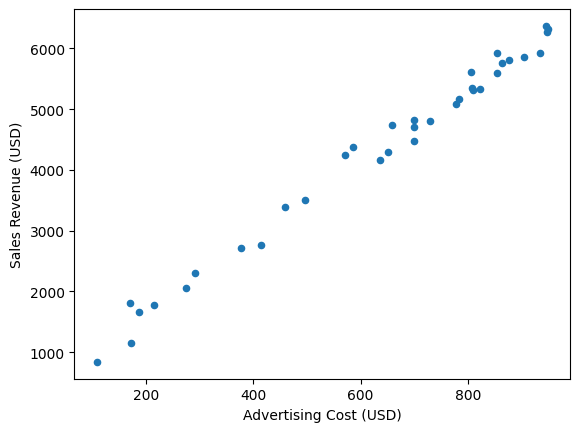

In [5]:
df.plot.scatter(
    x = 'Advertising Cost (USD)',
    y = 'Sales Revenue (USD)'
)
plt.show()

# **Hồi quy tuyến tính - Linear Regression**

- Khái niệm:
    + Hồi quy tuyến tính là 1 phương pháp mô tả mối quan hệ giữa 2 bên
    + Đường hồi quy tuyến tính là đường thẳng khớp nhất với tất cả các điểm dữ liệu
- Công thức: **y = ax + b**
- Trong đó:
    + x là biến độc lập
    + y là biến phụ thuộc
    + a là độc dốc (slope)
    + b là hệ số chặn (intercept)

**Áp dụng mô hình tuyến tính:** tạo mô hình - Xác định biến - Huấn luyện mô hình

In [7]:
# Tạo mô hình
model = LinearRegression()

# Xác định biến
    # x là Advertising Cost (chi phí)
x = df[['Advertising Cost (USD)']]
    # y là Sales Revenue (doanh thu)
y = df['Sales Revenue (USD)']

# Huấn luyện mô hình
model.fit(x, y)


LinearRegression()

In [8]:
# Tìm độc dốc (coef) - biến a trong y = ax + b
model.coef_

array([6.14733189])

In [9]:
# Tìm hệ số chặn (intercept) - biến b trong y = ax + b
model.intercept_

np.float64(423.6452982731562)

## **Tương quan (correlation)**
- Chỉ độ mạnh yếu mổi mối quan hệ giữa các giá trị
- Hệ số tương quan (corr) nằm trong khoảng từ -1 đến 1: <br>
    + corr = 1: cả 2 biến tăng cùng nhau <br>
    + corr = -1: một biến tăng, một biến giảm <br>
    + corr = 0: không có mối tương quan tuyến tính

In [10]:
# corr(): tính hệ số tương quan giữa 2 Series
df['Sales Revenue (USD)'].corr(df['Advertising Cost (USD)'])

np.float64(0.9940740630509901)

## **Best of fit**
- Mô tả mức độ phù hợp của mô hình với dữ liệu thực tế
- Đường best of fit càng gần với các điểm dữ liệu thì càng phù hợp

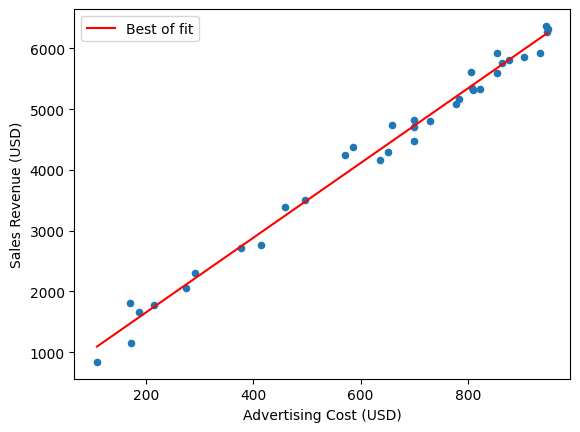

In [11]:
# Sử dụng lại Scatter Plot ở trên
df.plot.scatter(
    x="Advertising Cost (USD)",
    y="Sales Revenue (USD)"
)

# Tạo 1 mảng x từ nhỏ nhất đến lớn nhất (x của đường hồi quy - best of fit)
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
# Tính các giá trị y tương ứng với x_line vừa tạo: y = ax + b
y_line = model.coef_[0] * x_line + model.intercept_

# Vẽ đường best of fit
plt.plot(x_line, y_line, color='red', label='Best of fit')
plt.legend() # hiện chú thích cho các đường cột, điểm,...
plt.show()

In [18]:
# Dự đoán doanh thu khi chi phí quảng cáo là 600 USD
model.predict(pd.DataFrame([600]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4112.04443118])

## **Train - Test - Đánh giá hiệu quả**

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

train_test_split: dùng để chia dữ liệu thành 2 phần
- training set (tập huấn luyện): dùng để huấn luyện mô hình
- test set (tập kiểm tra): dùng để đánh giá mô hình, kiểm tra mức độ khái quát

In [15]:
# x: dữ liệu đầu vào (features)
# y: nhãn/tên bảng, giá trị mục tiêu
# test_size: tỉ lệ của training_set (0.2 nghĩa là lấy 20% dữ liệu để kiểm tra)
# random_state: giá trị cố định việc chia dữ liệu (nên để nguyên)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(28, 1) (28,)
(7, 1) (7,)


In [17]:
# Tạo model mới từ x,y sau khi train
new_model = LinearRegression()
new_model.fit(x_train, y_train)

LinearRegression()

In [20]:
# Test
y_pred = new_model.predict(x_test)
print(y_pred)

[5201.31263267 4727.07552127 4733.15548424 4435.23729888 3954.92022451
 1522.93503786 5371.55159574]


In [22]:
# Tìm hệ số a, b
new_model.intercept_, new_model.coef_
print('Hệ số a:', new_model.coef_[0])
print('Hệ số b:', new_model.intercept_)

Hệ số a: 6.079962966635856
Hệ số b: 477.1814075958687


## **Đánh giá mô hình**

**mean_square_error (sai số bình phương trung bình)**
- Đánh giá hiệu suất mô hình
- Đo lường mức độ chênh lệch giữa thực tế (y_test) và dự đoán (y_pred) bằng cách tính trung bình của bình phương các sai số
- mse càng nhỏ thì mô hình càng tốt, mse = 0 thì dự đoán hoàn hảo

In [23]:
mse = mean_squared_error(y_test, y_pred)
mse

53852.56448015925

**r2_score (r^2, r-square)**
- Đánh giá mức độ khớp của mô hình với dữ liệu
- Thể hiện tỉ lệ phần trăm chính xác của dự đoán so với thực tế

In [24]:
r2 = r2_score(y_test, y_pred)
r2      # r2 = 0.9696 có nghĩa là dự đoán đúng 96.96% so với thực tế

0.9696953486116257